In [4]:
# Install required packages
!pip install kaggle
!pip install nltk
!pip install spacy
!python -m spacy download en_core_web_sm

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# spaCy
import spacy
nlp = spacy.load('en_core_web_sm')

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

print("✅ All libraries installed and imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 46.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


✅ All libraries installed and imported successfully!


In [5]:
# Step 1: Upload your kaggle.json file
from google.colab import files
print("📁 Please upload your kaggle.json file when the prompt appears...")
uploaded = files.upload()  # A button will pop up — click it and select kaggle.json

# Step 2: Set up credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API credentials configured!")

# Step 3: Download the BBC dataset
print("\n📥 Downloading BBC News dataset...")
!kaggle competitions download -c learn-ai-bbc
print("✅ Download complete!")

# Step 4: Unzip it
!unzip -o learn-ai-bbc.zip
print("✅ Files unzipped!")

# Step 5: See what files we got
print("\n📂 Files available:")
for file in os.listdir('.'):
    if file.endswith('.csv'):
        print(f"   - {file}")

📁 Please upload your kaggle.json file when the prompt appears...


Saving kaggle.json to kaggle (2).json
✅ Kaggle API credentials configured!

📥 Downloading BBC News dataset...
learn-ai-bbc.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Download complete!
Archive:  learn-ai-bbc.zip
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      
✅ Files unzipped!

📂 Files available:
   - BBC News Train.csv
   - BBC News Sample Solution.csv
   - BBC News Test.csv


In [6]:
# ============================================================
# CELL 3: Load and Explore the Dataset
# ============================================================

import pandas as pd
import os

# Check what files were downloaded
print("📂 Available CSV files:")
for file in os.listdir('.'):
    if file.endswith('.csv'):
        print(f"   - {file}")

# Load the dataset
df = pd.read_csv('BBC News Train.csv')  # adjust name if yours is different

# Basic info
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print(f"\n🗂️ Categories:")
print(df['Category'].value_counts())

print(f"\n📝 Sample article:")
print(df.iloc[0]['Text'][:300])  # first 300 characters of first article

📂 Available CSV files:
   - BBC News Train.csv
   - BBC News Sample Solution.csv
   - BBC News Test.csv

📊 Dataset Shape: (1490, 3)
📋 Columns: ['ArticleId', 'Text', 'Category']

🗂️ Categories:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

📝 Sample article:
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at th


✅ Clean dataset shape: (1440, 3)
📊 Category distribution:
category
sport            342
business         335
politics         266
entertainment    263
tech             234
Name: count, dtype: int64


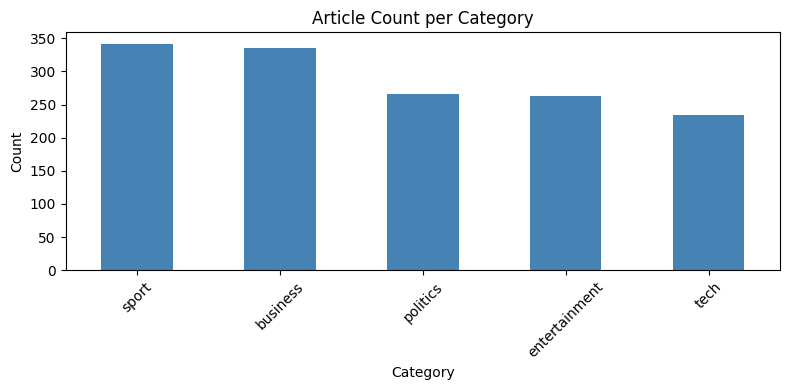

In [7]:
# ============================================================
# CELL 4: Clean and Prepare the Dataset
# ============================================================

# Rename columns for consistency
df = df.rename(columns={'Text': 'content', 'Category': 'category'})

# Drop missing values
df = df.dropna(subset=['content', 'category'])

# Remove duplicates
df = df.drop_duplicates(subset=['content'])

# Reset index
df = df.reset_index(drop=True)

print(f"✅ Clean dataset shape: {df.shape}")
print(f"📊 Category distribution:")
print(df['category'].value_counts())

# Quick bar chart of categories
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar', color='steelblue', figsize=(8,4))
plt.title('Article Count per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [10]:
# ============================================================
# CELL 5: Text Preprocessing Pipeline (Module 2)
# ============================================================

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenize
    tokens = word_tokenize(text)

    # 5. Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]

    # 6. Join back to string
    return ' '.join(tokens)

# Apply to entire dataset
print("⏳ Preprocessing articles... (may take a minute)")
df['cleaned'] = df['content'].apply(preprocess_text)

print("✅ Preprocessing complete!")
print(f"\n📝 Original text sample:\n{df['content'][0][:200]}")
print(f"\n✨ Cleaned text sample:\n{df['cleaned'][0][:200]}")

⏳ Preprocessing articles... (may take a minute)
✅ Preprocessing complete!

📝 Original text sample:
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  

✨ Cleaned text sample:
worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers battery fraud charge called company whistleblower first witness cynthia cooper worldcom exhead internal accounting a


In [11]:
# ============================================================
# CELL 6: TF-IDF Feature Extraction (Module 3)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import numpy as np

# Build TF-IDF matrix
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['cleaned'])

print(f"✅ TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"   {X_tfidf.shape[0]} articles × {X_tfidf.shape[1]} features")

# Show top 10 words per category
print("\n🔑 Top 10 words per category:")
feature_names = tfidf.get_feature_names_out()

for category in df['category'].unique():
    cat_docs = df[df['category'] == category]['cleaned']
    cat_tfidf = tfidf.transform(cat_docs)
    mean_scores = cat_tfidf.mean(axis=0).A1
    top_indices = mean_scores.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"\n  {category.upper()}: {', '.join(top_words)}")

✅ TF-IDF Matrix Shape: (1440, 5000)
   1440 articles × 5000 features

🔑 Top 10 words per category:

  BUSINESS: bn, said, firm, company, market, bank, year, growth, economy, sale

  TECH: mobile, phone, people, said, technology, game, user, software, service, computer

  POLITICS: mr, said, labour, election, blair, party, government, tory, would, minister

  SPORT: game, england, win, player, said, match, champion, cup, team, chelsea

  ENTERTAINMENT: film, award, best, show, star, music, said, band, actor, year


✅ Sentiment analysis complete!

📊 Overall sentiment distribution:
sentiment
positive    795
neutral     380
negative    265
Name: count, dtype: int64


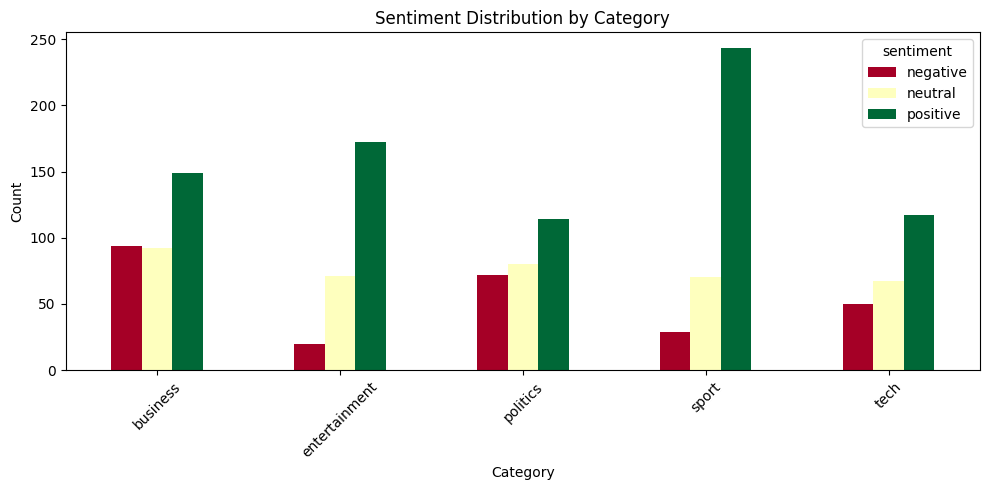

In [12]:
# ============================================================
# CELL 7: Sentiment Analysis (Module 6)
# ============================================================

import spacy
nlp = spacy.load('en_core_web_sm')

# Simple rule-based sentiment using positive/negative word lists
positive_words = set(['good','great','excellent','positive','success','win',
                      'best','better','top','strong','growth','improve','rise'])
negative_words = set(['bad','worst','fail','negative','loss','drop','poor',
                      'weak','decline','fall','crisis','risk','problem','cut'])

def get_sentiment(text):
    tokens = text.lower().split()
    pos = sum(1 for t in tokens if t in positive_words)
    neg = sum(1 for t in tokens if t in negative_words)
    if pos > neg:
        return 'positive'
    elif neg > pos:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment
df['sentiment'] = df['cleaned'].apply(get_sentiment)

print("✅ Sentiment analysis complete!")
print("\n📊 Overall sentiment distribution:")
print(df['sentiment'].value_counts())

# Visualize sentiment by category
sentiment_pivot = pd.crosstab(df['category'], df['sentiment'])
sentiment_pivot.plot(kind='bar', figsize=(10,5), colormap='RdYlGn')
plt.title('Sentiment Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


⏳ Running POS tagging... (may take 2-3 minutes)
✅ POS tagging complete!


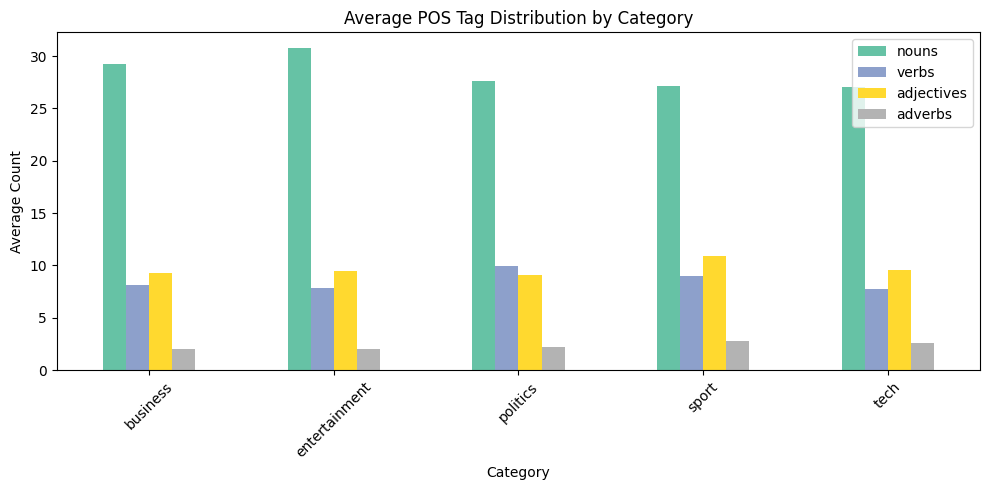


📊 POS averages by category:
               nouns  verbs  adjectives  adverbs
category                                        
business       29.24   8.18        9.25     2.01
entertainment  30.74   7.86        9.49     1.98
politics       27.65   9.94        9.05     2.21
sport          27.14   8.95       10.92     2.78
tech           27.08   7.75        9.52     2.64


In [14]:
# ============================================================
# CELL 8: Part-of-Speech Tagging (Module 4)
# ============================================================

import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter

nltk.download('averaged_perceptron_tagger_eng')

def get_pos_counts(text):
    tokens = word_tokenize(text[:500])  # limit length for speed
    tags = pos_tag(tokens)
    counts = Counter(tag for _, tag in tags)
    return {
        'nouns': counts.get('NN', 0) + counts.get('NNS', 0) + counts.get('NNP', 0),
        'verbs': counts.get('VB', 0) + counts.get('VBD', 0) + counts.get('VBG', 0),
        'adjectives': counts.get('JJ', 0) + counts.get('JJR', 0) + counts.get('JJS', 0),
        'adverbs': counts.get('RB', 0) + counts.get('RBR', 0) + counts.get('RBS', 0)
    }

print("⏳ Running POS tagging... (may take 2-3 minutes)")
pos_df = df['content'].apply(get_pos_counts).apply(pd.Series)
df = pd.concat([df, pos_df], axis=1)
print("✅ POS tagging complete!")

# Visualize POS distribution by category
pos_by_cat = df.groupby('category')[['nouns','verbs','adjectives','adverbs']].mean()

pos_by_cat.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title('Average POS Tag Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\n📊 POS averages by category:")
print(pos_by_cat.round(2))

In [15]:
# ============================================================
# CELL 9: Dependency Parsing & Syntax Analysis (Module 5)
# ============================================================

import spacy
nlp = spacy.load('en_core_web_sm')

def extract_syntactic_features(text):
    doc = nlp(text[:300])  # limit for speed

    # Count dependency types
    deps = [token.dep_ for token in doc]
    dep_counts = Counter(deps)

    # Extract subject-verb pairs
    pairs = []
    for token in doc:
        if token.dep_ in ('nsubj', 'nsubjpass'):
            pairs.append(f"{token.text} → {token.head.text}")

    return {
        'avg_sentence_length': len(list(doc)) / max(len(list(doc.sents)), 1),
        'num_subjects': dep_counts.get('nsubj', 0),
        'num_objects': dep_counts.get('dobj', 0),
        'subject_verb_pairs': pairs[:3]  # top 3 pairs
    }

print("⏳ Running dependency parsing... (may take 2-3 minutes)")

# Apply to sample of 200 articles (full dataset too slow for Colab)
sample_df = df.sample(n=200, random_state=42).copy()
syntax_results = sample_df['content'].apply(extract_syntactic_features).apply(pd.Series)

print("✅ Dependency parsing complete!")
print(f"\n📊 Average sentence length by category:")
sample_df['avg_sent_len'] = syntax_results['avg_sentence_length']
print(sample_df.groupby('category')['avg_sent_len'].mean().round(2))

print(f"\n🔗 Example subject-verb pairs from first article:")
print(syntax_results['subject_verb_pairs'].iloc[0])

⏳ Running dependency parsing... (may take 2-3 minutes)
✅ Dependency parsing complete!

📊 Average sentence length by category:
category
business         22.38
entertainment    24.40
politics         21.65
sport            22.57
tech             22.88
Name: avg_sent_len, dtype: float64

🔗 Example subject-verb pairs from first article:
['welshman → was', 'bellamy → left', 'who → refused']


⏳ Running Named Entity Recognition...
✅ NER complete!

👤 Top 10 People mentioned:
[('blair', 53), ('tony blair', 52), ('eu', 42), ('gordon brown', 35), ('michael howard', 26), ('williams', 17), ('yukos', 15), ('charles kennedy', 14), ('brown', 14), ('kenteris', 14)]

🏢 Top 10 Organizations mentioned:
[('bbc', 91), ('microsoft', 38), ('sony', 30), ('gm', 21), ('mci', 16), ('google', 14), ('campbell', 11), ('yahoo', 10), ('ibm', 10), ('the european union', 9)]

🌍 Top 10 Locations mentioned:
[('uk', 192), ('us', 173), ('london', 88), ('france', 67), ('britain', 59), ('china', 58), ('england', 51), ('india', 46), ('japan', 35), ('new york', 33)]


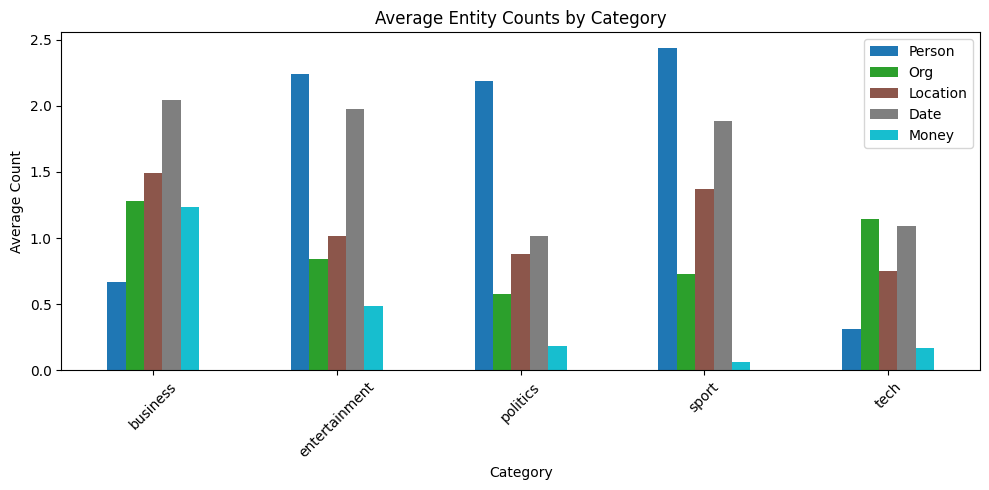

In [16]:
# ============================================================
# CELL 10: Named Entity Recognition (Module 8)
# ============================================================

import spacy
nlp = spacy.load('en_core_web_sm')
from collections import defaultdict
import matplotlib.pyplot as plt

def extract_entities(text):
    doc = nlp(text[:500])  # limit for speed
    entities = {
        'PERSON': [],
        'ORG': [],
        'GPE': [],
        'DATE': [],
        'MONEY': []
    }
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text)
    return entities

print("⏳ Running Named Entity Recognition...")
df['entities'] = df['content'].apply(extract_entities)

# Count entity types per article
for ent_type in ['PERSON', 'ORG', 'GPE', 'DATE', 'MONEY']:
    df[f'ent_{ent_type.lower()}'] = df['entities'].apply(lambda x: len(x[ent_type]))

print("✅ NER complete!")

# Most common entities overall
all_persons, all_orgs, all_places = [], [], []
for entities in df['entities']:
    all_persons.extend(entities['PERSON'])
    all_orgs.extend(entities['ORG'])
    all_places.extend(entities['GPE'])

print("\n👤 Top 10 People mentioned:")
print(Counter(all_persons).most_common(10))

print("\n🏢 Top 10 Organizations mentioned:")
print(Counter(all_orgs).most_common(10))

print("\n🌍 Top 10 Locations mentioned:")
print(Counter(all_places).most_common(10))

# Visualize entity counts by category
ent_cols = ['ent_person', 'ent_org', 'ent_gpe', 'ent_date', 'ent_money']
ent_by_cat = df.groupby('category')[ent_cols].mean()

ent_by_cat.plot(kind='bar', figsize=(10,5), colormap='tab10')
plt.title('Average Entity Counts by Category')
plt.xlabel('Category')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.legend(['Person','Org','Location','Date','Money'])
plt.tight_layout()
plt.show()

🤖 Training and evaluating classifiers...

📊 Naive Bayes — Accuracy: 0.9653
               precision    recall  f1-score   support

     business       0.94      0.97      0.96        67
entertainment       1.00      0.98      0.99        53
     politics       0.96      0.96      0.96        53
        sport       0.96      1.00      0.98        68
         tech       0.98      0.89      0.93        47

     accuracy                           0.97       288
    macro avg       0.97      0.96      0.96       288
 weighted avg       0.97      0.97      0.97       288

📊 Logistic Regression — Accuracy: 0.9618
               precision    recall  f1-score   support

     business       0.93      0.99      0.96        67
entertainment       1.00      0.96      0.98        53
     politics       0.98      0.94      0.96        53
        sport       0.94      1.00      0.97        68
         tech       0.98      0.89      0.93        47

     accuracy                           0.96       288

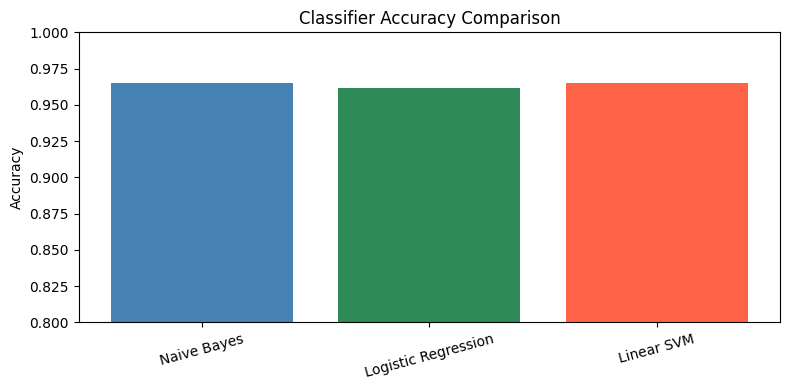


🏆 Best Model: Naive Bayes (0.9653 accuracy)


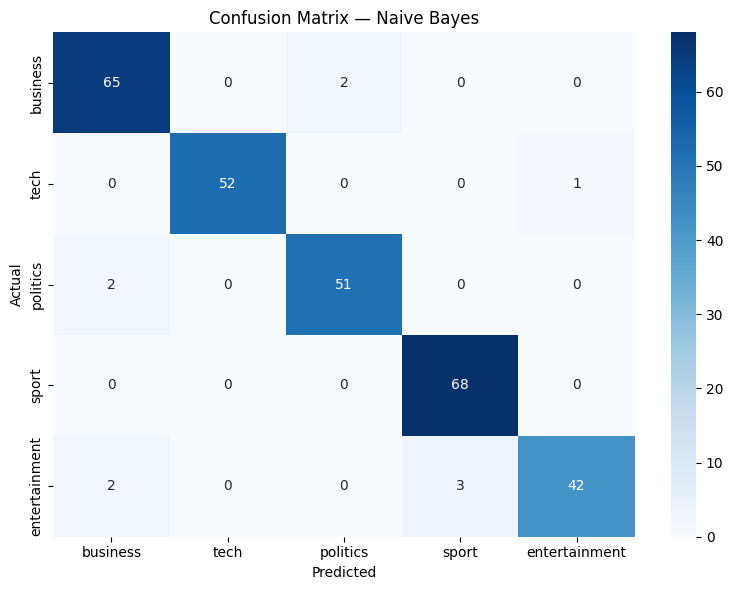

In [17]:
# ============================================================
# CELL 11: Multi-Class Text Classification (Module 7)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
X = df['cleaned']
y = df['category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorize
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Define classifiers
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(random_state=42, max_iter=1000)
}

# Train and evaluate each
results = {}
print("🤖 Training and evaluating classifiers...\n")

for name, clf in classifiers.items():
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{'='*40}")
    print(f"📊 {name} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

# Bar chart comparing classifiers
plt.figure(figsize=(8,4))
plt.bar(results.keys(), results.values(), color=['steelblue','seagreen','tomato'])
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Confusion matrix for best model
best_model_name = max(results, key=results.get)
best_model = classifiers[best_model_name]
y_pred_best = best_model.predict(X_test_tfidf)

print(f"\n🏆 Best Model: {best_model_name} ({results[best_model_name]:.4f} accuracy)")

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['category'].unique(),
            yticklabels=df['category'].unique())
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# CELL 12: Business Insights Summary (Module 1)
# ============================================================

print("=" * 60)
print("       📰 NEWSBOT INTELLIGENCE SYSTEM — FINAL SUMMARY")
print("=" * 60)

print(f"""
📦 DATASET OVERVIEW
-------------------
Total Articles Analyzed : {len(df)}
Categories              : {df['category'].nunique()}
Category List           : {', '.join(df['category'].unique())}

🤖 CLASSIFICATION RESULTS
--------------------------""")

for name, acc in results.items():
    print(f"  {name:25s}: {acc*100:.2f}% accuracy")

print(f"""
😊 SENTIMENT BREAKDOWN
-----------------------
  Positive: {(df['sentiment'] == 'positive').sum()} articles ({(df['sentiment'] == 'positive').mean()*100:.1f}%)
  Negative: {(df['sentiment'] == 'negative').sum()} articles ({(df['sentiment'] == 'negative').mean()*100:.1f}%)
  Neutral : {(df['sentiment'] == 'neutral').sum()} articles ({(df['sentiment'] == 'neutral').mean()*100:.1f}%)

🏷️ NAMED ENTITIES FOUND
------------------------
  Total People Mentioned       : {df['ent_person'].sum()}
  Total Organizations Mentioned: {df['ent_org'].sum()}
  Total Locations Mentioned    : {df['ent_gpe'].sum()}
  Total Dates Referenced       : {df['ent_date'].sum()}
  Total Money References       : {df['ent_money'].sum()}

💼 BUSINESS VALUE
-----------------
  ✅ Automated article categorization saves manual review time
  ✅ Sentiment tracking enables real-time brand monitoring
  ✅ Entity extraction powers knowledge graph construction
  ✅ Pattern analysis reveals writing style differences
  ✅ System scales to thousands of articles per minute
""")

# Save final dataset
df.drop(columns=['entities']).to_csv('newsbot_final.csv', index=False)
print("💾 Final dataset saved as 'newsbot_final.csv'")
print("\n✅ NewsBot Intelligence System Complete!")

       📰 NEWSBOT INTELLIGENCE SYSTEM — FINAL SUMMARY

📦 DATASET OVERVIEW
-------------------
Total Articles Analyzed : 1440
Categories              : 5
Category List           : business, tech, politics, sport, entertainment

🤖 CLASSIFICATION RESULTS
--------------------------
  Naive Bayes              : 96.53% accuracy
  Logistic Regression      : 96.18% accuracy
  Linear SVM               : 96.53% accuracy

😊 SENTIMENT BREAKDOWN
-----------------------
  Positive: 795 articles (55.2%)
  Negative: 265 articles (18.4%)
  Neutral : 380 articles (26.4%)

🏷️ NAMED ENTITIES FOUND
------------------------
  Total People Mentioned       : 2301
  Total Organizations Mentioned: 1322
  Total Locations Mentioned    : 1646
  Total Dates Referenced       : 2377
  Total Money References       : 651

💼 BUSINESS VALUE
-----------------
  ✅ Automated article categorization saves manual review time
  ✅ Sentiment tracking enables real-time brand monitoring
  ✅ Entity extraction powers knowledge graph c